# ML-testbed 13 — connect the LM to inference tools

The language model proposes an action. A bounded runtime validates it, executes a numerical tool, and returns a traceable result. We separate syntax, tool choice, numerical execution and scientific adequacy, because success at one does not guarantee success at the others.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** agent interfaces, JSON schema validation, tool boundaries, evidence references, behavioral evaluation, failure records

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. The candidate receives only permitted observations
This notebook uses the tiny LM from lesson 12, retrained locally with the same fixed recipe so it runs independently. Each record contains the request and reconstructed summaries. Missing values are actually removed from the available information by replacing their slots with NaN. The thermal family is not exposed in this agent task. Evaluator truth stays separate.

This lesson runs a bounded single-decision episode. Asking for a missing diagnostic ends the episode as `needs_measurement`; the system never invents the requested measurement.

In [2]:
from ml_testbed.language import train_lm, partitions, expected_tool, generate, constrained_call
from ml_testbed.runtime import run_agent, dispatch
seed_all(12); lm,lm_history=train_lm()
_,_,cases_eval=partitions()
records=[]; truths=[]
for i,case in enumerate(cases_eval):
    theta=draw_parameters(1,13000+i); theta[:,2]=.22
    with torch.no_grad(): summary=summaries(theta)[0]+torch.randn(12)*SUMMARY_SIGMA
    summary[9:]=float('nan')
    if not case['current']: summary[:3]=float('nan')
    if not case['motion']: summary[3:9]=float('nan')
    records.append({'case':case,'summaries':summary,'shot_id':f'development-{i}'})
    truths.append(theta[0])
print('First permitted request:',records[0]['case'])
print('First permitted summary slots:',records[0]['summaries'])

First permitted request: {'question': 'charge', 'current': False, 'motion': False, 'clock': False}
First permitted summary slots: tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])


### Visual lab — Keep the language model and numerical evidence separate

The LM selects an action. The runtime checks the call and information requirements. Only then does a numerical tool calculate a conditional estimate. Unsupported requests or missing observations lead to a request, rejection or unresolved result.

**Notice:** evaluator truth is outside this path. A returned evidence identifier points back to observations; it does not certify the physical interpretation.

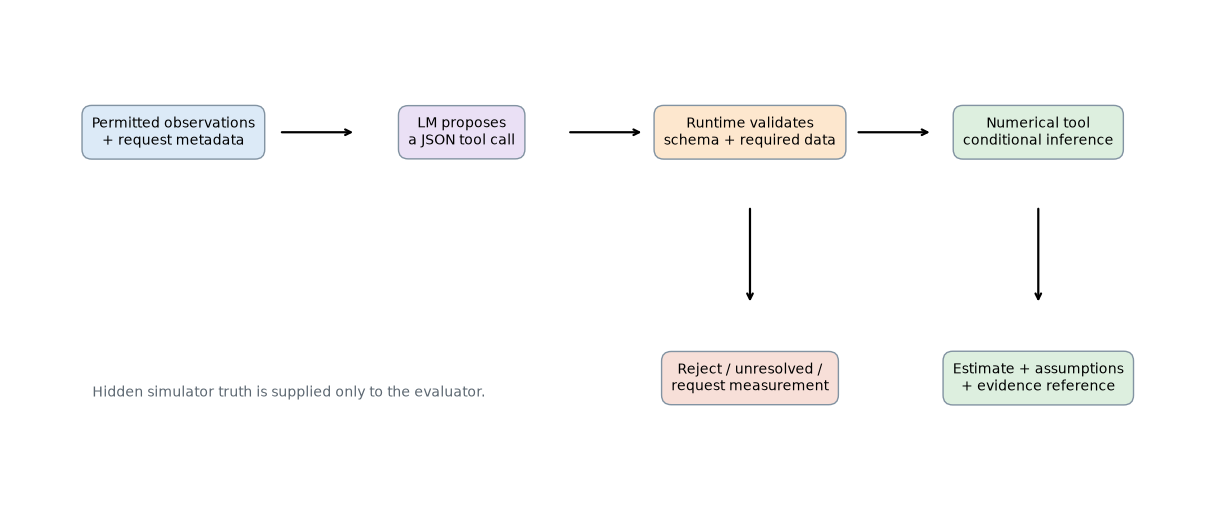

In [3]:
v_fig,v_ax=plt.subplots(figsize=(12,5),layout='constrained'); v_ax.axis('off')
v_nodes=[(0,1,'Permitted observations\n+ request metadata','#dceaf7'),(3,1,'LM proposes\na JSON tool call','#eae0f5'),(6,1,'Runtime validates\nschema + required data','#fde7ce'),(9,1,'Numerical tool\nconditional inference','#ddefdf'),(6,-1,'Reject / unresolved /\nrequest measurement','#f7dfd8'),(9,-1,'Estimate + assumptions\n+ evidence reference','#ddefdf')]
for v_x,v_y,v_text,v_color in v_nodes:
    v_ax.text(v_x,v_y,v_text,ha='center',va='center',fontsize=10,bbox=dict(boxstyle='round,pad=.7',fc=v_color,ec='#8293a2'))
for v_x in [0,3,6]:v_ax.annotate('',xy=(v_x+1.9,1),xytext=(v_x+1.1,1),arrowprops=dict(arrowstyle='->',lw=1.6))
for v_x in [6,9]:v_ax.annotate('',xy=(v_x,-.4),xytext=(v_x,.4),arrowprops=dict(arrowstyle='->',lw=1.6))
v_ax.text(1.2,-1.15,'Hidden simulator truth is supplied only to the evaluator.',ha='center',fontsize=10,color='#5c6771',wrap=True)
v_ax.set(xlim=(-1.7,10.7),ylim=(-2,2)); plt.show()

## 2. Inspect the tool contract
`infer` returns a conditional grid estimate or abstains. It requires the relevant channels and known timing. Resistance is fixed at .22. The tool rejects a large posterior predictive residual using a teaching threshold of four sigma. That residual gate is heuristic and has no guaranteed false-alarm rate.

`align` requests an independent calibration. It does not line up unrelated peaks. `request_*` returns a measurement request. Every valid result links to a hash of the permitted observation record. An evidence ID establishes provenance, not physical correctness.

In [4]:
import inspect
print(inspect.getsource(dispatch))

def dispatch(call,record):
    """No evaluator truth, arbitrary execution, filesystem paths or facility control."""
    if parse_call(json.dumps(call)) is None:
        return {'status':'rejected','reason':'invalid tool schema'}
    tool=call['tool']; case=record['case']; evidence=evidence_id(record)
    if tool.startswith('request_'):
        return {'status':'needs_measurement','requested':tool.removeprefix('request_'),'evidence':[evidence]}
    if tool=='align':
        return {'status':'needs_calibration','reason':'supply independent timing fiducial; no alignment inferred by matching peaks',
                'evidence':[evidence]}
    if case['question']=='growth':
        return {'status':'unresolved','reason':'growth absent from summary operator','evidence':[evidence]}
    if not case['clock'] or not case['current'] or (case['question']=='mass' and not case['motion']):
        return {'status':'unresolved','reason':'required information missing','evidence':[evidence]}
    obs=reco

## 3. Compare policies on the same records
The conventional rule is the authored policy used to label the toy LM data. It is therefore a strong baseline here. “Always infer” tests runtime guard behavior. Raw LM and constrained LM differ in output syntax handling. Model choice is scored independently of the runtime's ability to prevent an invalid estimate.

In [5]:
policies={'rule':lambda case:{'tool':expected_tool(case)},
          'always infer':lambda case:{'tool':'infer'},
          'raw LM':lambda case:generate(lm,case),
          'constrained LM':lambda case:constrained_call(lm,case)}
rows=[]; traces=[]
for name,policy in policies.items():
    for record,truth in zip(records,truths):
        start=time.perf_counter(); result=run_agent(policy,record,max_calls=2)
        call=result['trace'][0]['call']['tool'] if result['trace'] else None
        final=result['final']; expected=expected_tool(record['case'])
        row={'policy':name,'shot':record['shot_id'],'tool':call,'expected_tool':expected,
             'tool_correct':call==expected,'status':final['status'],'calls':result['calls'],
             'seconds':time.perf_counter()-start,'truth_covered':None}
        if final['status']=='conditional_estimate':
            index=0 if record['case']['question']=='charge' else 1
            row['truth_covered']=final['interval90'][0]<=float(truth[index])<=final['interval90'][1]
        rows.append(row); traces.append({'policy':name,'shot':record['shot_id'],'episode':result})
display(rows)
metrics={name:{'tool_accuracy':np.mean([r['tool_correct'] for r in rows if r['policy']==name]),
               'estimated_cases':sum(r['status']=='conditional_estimate' for r in rows if r['policy']==name)} for name in policies}
print(metrics)

[{'policy': 'rule',
  'shot': 'development-0',
  'tool': 'request_current',
  'expected_tool': 'request_current',
  'tool_correct': True,
  'status': 'needs_measurement',
  'calls': 1,
  'seconds': 3.616698086261749e-05,
  'truth_covered': None},
 {'policy': 'rule',
  'shot': 'development-1',
  'tool': 'request_current',
  'expected_tool': 'request_current',
  'tool_correct': True,
  'status': 'needs_measurement',
  'calls': 1,
  'seconds': 1.4416989870369434e-05,
  'truth_covered': None},
 {'policy': 'rule',
  'shot': 'development-2',
  'tool': 'request_current',
  'expected_tool': 'request_current',
  'tool_correct': True,
  'status': 'needs_measurement',
  'calls': 1,
  'seconds': 1.4208955690264702e-05,
  'truth_covered': None},
 {'policy': 'rule',
  'shot': 'development-3',
  'tool': 'infer',
  'expected_tool': 'infer',
  'tool_correct': True,
  'status': 'conditional_estimate',
  'calls': 1,
  'seconds': 0.018816250027157366,
  'truth_covered': False},
 {'policy': 'always infer',

{'rule': {'tool_accuracy': np.float64(1.0), 'estimated_cases': 1}, 'always infer': {'tool_accuracy': np.float64(0.25), 'estimated_cases': 1}, 'raw LM': {'tool_accuracy': np.float64(0.75), 'estimated_cases': 0}, 'constrained LM': {'tool_accuracy': np.float64(0.75), 'estimated_cases': 0}}


### Visual lab — Separate choosing the right tool from producing an estimate

The matrix marks correct action choices for each policy and held-out case. The right panel counts conditional estimates returned by the runtime. An estimate count alone is not an accuracy score: sometimes the correct action is to request missing information.

**Notice:** the rule baseline uses the authored policy. The small evaluation has only four cases; inspect the individual failures.

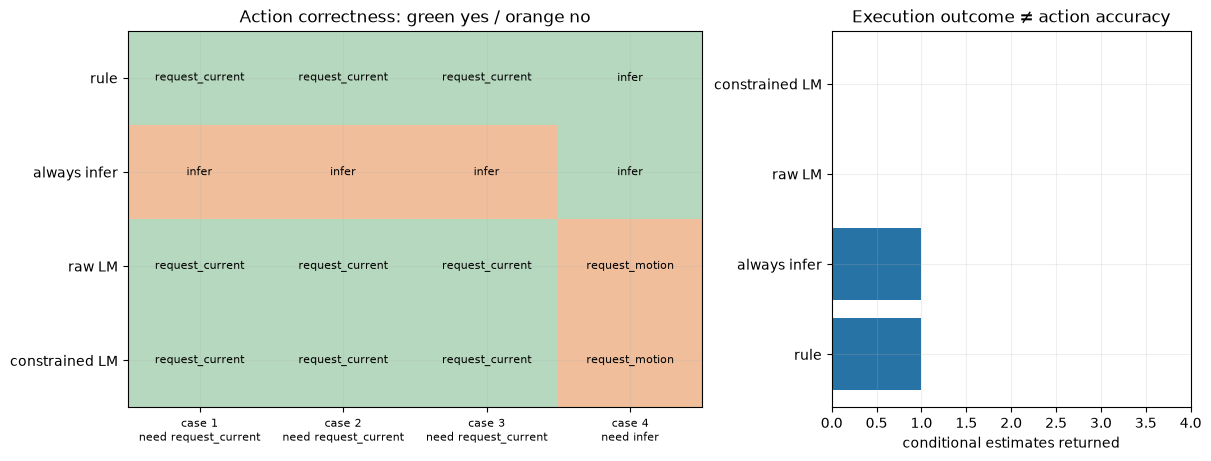

In [6]:
from matplotlib.colors import ListedColormap
v_policies=list(policies); v_shots=[v_record['shot_id'] for v_record in records]
v_correct=np.array([[next(v_row['tool_correct'] for v_row in rows if v_row['policy']==v_name and v_row['shot']==v_shot) for v_shot in v_shots] for v_name in v_policies])
v_fig,v_axes=plt.subplots(1,2,figsize=(12,4.5),gridspec_kw={'width_ratios':[1.6,1]},layout='constrained')
v_axes[0].imshow(v_correct,aspect='auto',cmap=ListedColormap(['#f0be9b','#b6d8be']),vmin=0,vmax=1)
for v_i,v_name in enumerate(v_policies):
    for v_j,v_shot in enumerate(v_shots):
        v_row=next(v_r for v_r in rows if v_r['policy']==v_name and v_r['shot']==v_shot)
        v_axes[0].text(v_j,v_i,v_row['tool'] or 'invalid',ha='center',va='center',fontsize=8)
v_axes[0].set(yticks=range(len(v_policies)),yticklabels=v_policies,xticks=range(len(v_shots)),
              xticklabels=[f'case {v_i+1}\nneed {expected_tool(v_record["case"])}' for v_i,v_record in enumerate(records)],title='Action correctness: green yes / orange no')
v_axes[0].tick_params(axis='x',labelsize=8)
v_estimates=[metrics[v_name]['estimated_cases'] for v_name in v_policies]
v_axes[1].barh(v_policies,v_estimates,color='#2873a6'); v_axes[1].set(xlim=(0,len(records)),xlabel='conditional estimates returned',title='Execution outcome ≠ action accuracy')
plt.show()

## 4. Test the boundary separately from the model
Malformed or unlisted calls must fail. A plausible request with missing information must not receive an unconditional estimate. The runtime never executes code produced by the model. This is a closed-schema teaching interface, not a full natural-language prompt-injection defense.

In [7]:
bad=run_agent(lambda c:'{"tool":"run_shell","command":"anything"}',records[0])
assert bad['final']['status']=='rejected'
missing={'case':{'question':'mass','current':False,'motion':False,'clock':False},'summaries':torch.full((12,),float('nan')),'shot_id':'missing'}
blocked=run_agent(lambda c:{'tool':'infer'},missing)
assert blocked['final']['status']=='unresolved'
print('Malformed call:',bad['final']); print('Missing-data call:',blocked['final'])
run=save_run(ROOT,'13',metrics,{'max_calls':2,'policy_model':'tiny causal Transformer','evaluation_cases':len(records)})
(run/'tool_traces.json').write_text(json.dumps(traces,indent=2))
(run/'evaluation.json').write_text(json.dumps(rows,indent=2))
print(run)

Malformed call: {'status': 'rejected', 'reason': 'invalid generated JSON'}
Missing-data call: {'status': 'unresolved', 'reason': 'required information missing', 'evidence': ['obs-ed4701c9336eedb3']}
/Users/operator/Desktop/Factor/runs/world-model/13-0db8e6cc07


### Visual lab — Read one actual tool trace

This panel follows a recorded episode from the evaluation above. It prefers an episode that returned an estimate, if one exists; the policy and shot are named explicitly. The original trace remains available as structured data.

**Ask:** which parts were proposed by the language policy, and which were computed or enforced by the runtime?

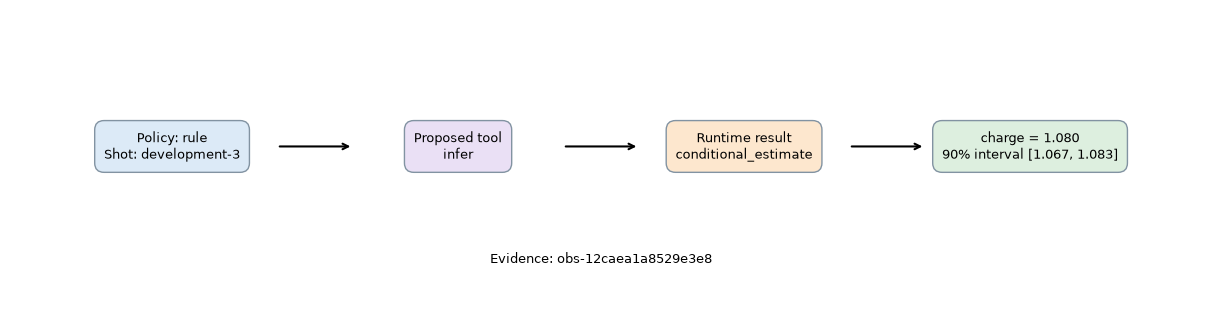

In [8]:
v_trace=next((v_item for v_item in traces if v_item['episode']['final']['status']=='conditional_estimate'),traces[0])
v_episode=v_trace['episode']; v_final=v_episode['final']; v_call=v_episode['trace'][0]['call'] if v_episode['trace'] else {'tool':'invalid'}
v_details=[f'Policy: {v_trace["policy"]}\nShot: {v_trace["shot"]}',f'Proposed tool\n{v_call["tool"]}',f'Runtime result\n{v_final["status"]}']
if 'interval90' in v_final: v_details.append(f'{v_final["parameter"]} = {v_final["mean"]:.3f}\n90% interval [{v_final["interval90"][0]:.3f}, {v_final["interval90"][1]:.3f}]')
else: v_details.append(v_final.get('reason','Additional information required'))
v_fig,v_ax=plt.subplots(figsize=(12,3.1),layout='constrained'); v_ax.axis('off')
for v_i,v_detail in enumerate(v_details):
    v_ax.text(v_i*3,0,v_detail,ha='center',va='center',fontsize=9,bbox=dict(boxstyle='round,pad=.75',fc=['#dceaf7','#eae0f5','#fde7ce','#ddefdf'][v_i],ec='#8293a2'))
    if v_i<3:v_ax.annotate('',xy=(v_i*3+1.9,0),xytext=(v_i*3+1.1,0),arrowprops=dict(arrowstyle='->',lw=1.5))
v_ax.text(4.5,-.85,'Evidence: '+', '.join(v_final.get('evidence',[])),ha='center',fontsize=9)
v_ax.set(xlim=(-1.7,10.8),ylim=(-1.2,1)); plt.show()

## 5. Optional: substitute an already-running local model
The numerical runtime stays unchanged. This optional cell uses a local OpenAI-compatible server on loopback, such as an existing LM Studio session. It is **off by default** and is not part of the saved verification. Set the model identifier to one already loaded in your server. Requests stay on this computer. Free-form text is parsed by the same strict schema; malformed responses are failures.

This is an adapter example, not a claim that a pretrained model has been evaluated here.

In [9]:
USE_LOCAL_LM=False
LOCAL_MODEL_ID=''  # Fill in the exact identifier of an already-loaded local model.
if USE_LOCAL_LM:
    if not LOCAL_MODEL_ID: raise ValueError('Set LOCAL_MODEL_ID to your loaded local model')
    import urllib.request
    from ml_testbed.language import TOOLS
    def local_policy(case):
        payload={'model':LOCAL_MODEL_ID,'temperature':0,'max_tokens':80,'messages':[
            {'role':'system','content':'Return only JSON with one key tool. Allowed tools: '+', '.join(TOOLS)+'. Choose needed evidence before inference. Growth requires image. Mass requires current and motion. Charge requires current. Unknown clock requires align.'},
            {'role':'user','content':json.dumps(case)}]}
        request=urllib.request.Request('http://127.0.0.1:1234/v1/chat/completions',
            data=json.dumps(payload).encode(),headers={'Content-Type':'application/json'})
        with urllib.request.urlopen(request,timeout=60) as response: data=json.load(response)
        return data['choices'][0]['message']['content']
    display(run_agent(local_policy,records[0]))
else:
    print('Optional local server disabled; executed results above use the trained tiny LM.')

Optional local server disabled; executed results above use the trained tiny LM.


## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Expand evaluation beyond four toy cases: include wrong calibration, contradictory channels, malformed calls and unsupported questions.
2. Add a real second observation-acquisition turn while keeping the new measurement separate from evaluator truth.
3. Connect Factor’s provider abstraction to this runtime and compare models using identical observations, budgets and numerical tools.